In [22]:
# ============================================================
# NOTEBOOK 2: ANÁLISIS DE HIPÓTESIS
# ============================================================
# Este notebook parte del dataset limpio que generé en el Notebook 1.
# Aquí cargo el CSV final y analizo las 5 hipótesis del proyecto,
# usando visualizaciones y tests estadísticos para validarlas.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats  # Contiene la función pearsonr para medir correlaciones
import plotly.express as px   # Para gráficos interactivos (pasar el ratón = ver datos)

# Las gráficas aparecen directamente en el notebook
%matplotlib inline

# Estilo visual: fondo blanco con rejilla suave
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Desactivo warnings para que el output esté limpio
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [10]:
# ============================================================
# CARGAR EL DATASET LIMPIO DEL NOTEBOOK 1
# ============================================================
# En el Notebook 1 limpié y mergée 8 datasets de Eurostat y
# guardé el resultado en dataset_europa_final.csv.
# Aquí lo cargo directamente para no repetir todo ese proceso.
# pd.read_csv() lee un archivo CSV y lo convierte en DataFrame.
# ============================================================

df = pd.read_csv('./data/dataset_europa_final.csv')

print(f"Dataset cargado: {len(df)} filas × {len(df.columns)} columnas")
print(f"Columnas: {df.columns.tolist()}")
print(f"Rango temporal: {df['anio'].min()} - {df['anio'].max()}")
print(f"Países: {df['geo'].nunique()}")

Dataset cargado: 1016 filas × 12 columnas
Columnas: ['geo', 'anio', 'salario_min_eur', 'salario_min_pps', 'pib_pps', 'indice_vivienda', 'gini', 'brecha_genero', 'pobreza_laboral', 'tasa_desempleo', 'inflacion_hicp', 'es_eu27']
Rango temporal: 1999 - 2026
Países: 38


In [12]:
# ============================================================
# EXPLORACIÓN RÁPIDA
# ============================================================
# Cada vez que cargo un CSV en un notebook nuevo, lo primero
# es verificar que los tipos de datos son correctos.
# Si 'anio' se cargó como texto en vez de número, me reventaría
# una gráfica más adelante. Mejor pillarlo aquí.
# ============================================================

print("Tipos de datos:")
print(df.dtypes)
print(f"\nPrimeras filas:")
df.head(35)

Tipos de datos:
geo                    str
anio                 int64
salario_min_eur    float64
salario_min_pps    float64
pib_pps            float64
indice_vivienda    float64
gini               float64
brecha_genero      float64
pobreza_laboral    float64
tasa_desempleo     float64
inflacion_hicp     float64
es_eu27               bool
dtype: object

Primeras filas:


,geo,anio,salario_min_eur,salario_min_pps,pib_pps,indice_vivienda,gini,brecha_genero,pobreza_laboral,tasa_desempleo,inflacion_hicp,es_eu27
0,AL,1999,45.0,89.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,AL,2000,49.5,99.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,AL,2001,56.5,107.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,AL,2002,65.5,123.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,AL,2003,70.5,143.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
5,AL,2004,81.5,154.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
6,AL,2005,90.0,168.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
7,AL,2006,105.0,189.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
8,AL,2007,114.0,204.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
9,AL,2008,135.0,237.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [13]:
# ============================================================
# RESUMEN ESTADÍSTICO
# ============================================================
# .describe() es como un chequeo médico del dataset.
# Para cada columna numérica calcula:
#   count = cuántos valores NO son NaN (me dice cuántos datos tengo)
#   mean  = la media (promedio)
#   std   = desviación estándar (cuánto se dispersan los datos)
#   min   = valor mínimo
#   25%   = primer cuartil (el 25% de los datos están por debajo)
#   50%   = mediana (el valor del medio, más robusto que la media)
#   75%   = tercer cuartil
#   max   = valor máximo
#
# Si veo algo raro (un salario negativo, un Gini de 200), sé que
# hay un error de limpieza que tengo que arreglar.
# ============================================================

df.describe().round(2)

,anio,salario_min_eur,salario_min_pps,pib_pps,indice_vivienda,gini,brecha_genero,pobreza_laboral,tasa_desempleo,inflacion_hicp
count,1016.00,728.00,697.00,424.00,278.00,303.00,495.00,704.00,583.00,914.00
mean,2012.69,689.88,773.87,96.63,146.28,30.23,14.33,8.16,8.81,99.21
std,7.96,558.23,422.70,47.08,48.66,4.66,6.25,3.17,5.28,53.85
min,1999.00,2.00,29.00,29.00,74.32,20.90,-2.20,2.50,2.00,8.58
25%,2006.00,254.88,439.00,67.00,110.56,27.00,9.60,5.80,5.20,83.12
50%,2013.00,522.50,723.00,88.00,135.31,29.80,15.00,7.70,7.30,99.10
75%,2020.00,1051.00,1078.00,121.00,170.70,32.85,18.55,10.10,10.60,105.07
max,2026.00,2704.00,2157.00,280.00,347.43,45.30,30.90,19.70,32.20,1221.20


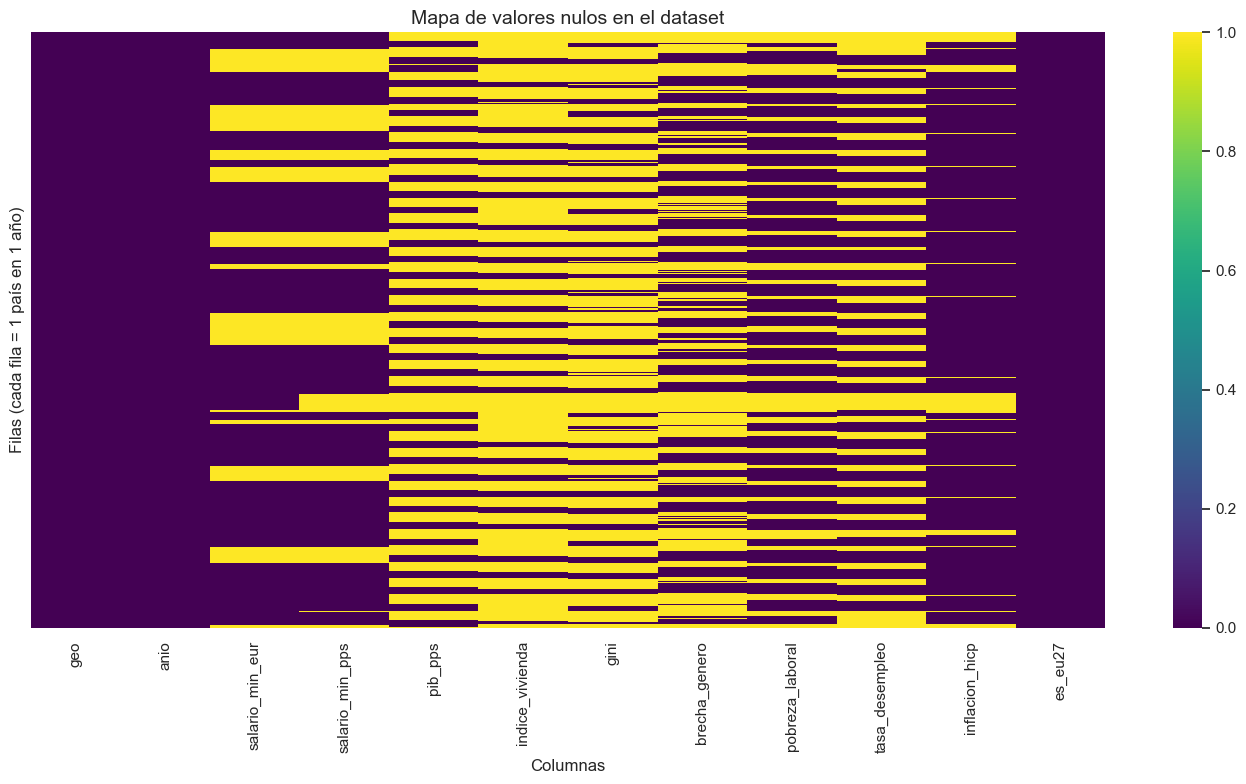


Nulos por columna:
                 nulos  % del total
indice_vivienda    738         72.6
gini               713         70.2
pib_pps            592         58.3
brecha_genero      521         51.3
tasa_desempleo     433         42.6
salario_min_pps    319         31.4
pobreza_laboral    312         30.7
salario_min_eur    288         28.3
inflacion_hicp     102         10.0


In [14]:
# ============================================================
# VISUALIZACIÓN DE NULOS
# ============================================================
# Un heatmap (mapa de calor) me permite ver de un vistazo dónde
# están los huecos en mis datos.
#
# ¿Qué es un heatmap?
# Es una tabla donde cada celda tiene un color en vez de un número.
# Aquí: amarillo = hay dato, morado = falta dato (NaN).
#
# ¿Por qué me importan los nulos?
# Porque cada hipótesis usa columnas distintas. Si la columna
# 'brecha_genero' tiene un 50% de NaN, solo puedo analizar H2
# con la mitad de los datos. Necesito saber esto ANTES de empezar.
#
# sns.heatmap() dibuja el mapa de calor
# df.isnull() convierte cada celda en True (NaN) o False (tiene dato)
# cmap='viridis' es la paleta de colores (amarillo-verde-morado)
# yticklabels=False quita las etiquetas del eje Y (con 1016 filas
# serían ilegibles y ralentizarían el notebook)
# ============================================================

plt.figure(figsize=(14, 8))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis')
plt.title('Mapa de valores nulos en el dataset', fontsize=14)
plt.xlabel('Columnas')
plt.ylabel('Filas (cada fila = 1 país en 1 año)')
plt.tight_layout()
plt.show()

# Resumen numérico: el gráfico es para presentar, las cifras para ser preciso
print("\nNulos por columna:")
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(1)
resumen_nulos = pd.DataFrame({'nulos': nulos, '% del total': pct_nulos})
print(resumen_nulos[resumen_nulos['nulos'] > 0].sort_values('% del total', ascending=False))

In [15]:
# ============================================================
# CONFIGURACIÓN PARA EL ANÁLISIS
# ============================================================
# Defino las listas de países (las mismas del Notebook 1) y una
# función reutilizable para el test de Pearson.
#
# ¿Qué es una función?
# Es un bloque de código con nombre que puedo llamar cuando quiera.
# En vez de escribir las mismas 15 líneas cada vez que quiero
# hacer un test de Pearson, las escribo UNA vez dentro de la
# función y luego la llamo con una sola línea.
# Es como crear mi propia herramienta dentro de Python.
#
# La sintaxis es:
#   def nombre_funcion(parametros):
#       ...código...
#       return resultado
#
# Y la llamo así:
#   resultado = nombre_funcion(mis_datos)
# ============================================================

eu27 = ['AT','BE','BG','CY','CZ','DE','DK','EE','EL','ES',
        'FI','FR','HR','HU','IE','IT','LT','LU','LV','MT',
        'NL','PL','PT','RO','SE','SI','SK']

extra_europeos = ['NO','CH','IS','UK','RS','TR','ME','MK','AL','BA','MD']

paises_europa = eu27 + extra_europeos


def test_pearson(df_input, col_x, col_y, nombre_test=""):
    """
    Realiza el test de correlación de Pearson entre dos columnas.
    
    Recibe:
    - df_input: el DataFrame con los datos
    - col_x: nombre de la primera columna (ej: 'salario_min_eur')
    - col_y: nombre de la segunda columna (ej: 'gini')
    - nombre_test: un texto descriptivo para identificar el resultado
    
    Devuelve: (r, p_value)
    - r: coeficiente de correlación (-1 a +1)
    - p_value: probabilidad de que sea casualidad (si < 0.05, es significativa)
    """
    # dropna() elimina las filas donde alguna de las dos columnas es NaN.
    # Pearson necesita que AMBOS valores existan en cada fila.
    # Si un país tiene salario pero no Gini, esa fila no puede participar.
    datos = df_input[[col_x, col_y]].dropna()
    
    # Protección: si quedan menos de 3 filas, Pearson no tiene sentido
    if len(datos) < 3:
        print(f"  {nombre_test}: datos insuficientes ({len(datos)} filas)")
        return None, None
    
    # stats.pearsonr() es la función de SciPy que hace el cálculo
    # Devuelve dos valores: r (correlación) y p_value
    corr, p_value = stats.pearsonr(datos[col_x], datos[col_y])
    
    # Interpreto la fuerza de la correlación
    abs_corr = abs(corr)
    if abs_corr < 0.3:
        fuerza = "débil"
    elif abs_corr < 0.5:
        fuerza = "moderada"
    elif abs_corr < 0.7:
        fuerza = "notable"
    else:
        fuerza = "fuerte"
    
    direccion = "positiva" if corr > 0 else "negativa"
    significativa = "SÍ" if p_value < 0.05 else "NO"
    
    print(f"  {nombre_test}")
    print(f"    Observaciones válidas: {len(datos)}")
    print(f"    Correlación (r): {corr:.4f} ({fuerza}, {direccion})")
    print(f"    P-value: {p_value:.6f}")
    print(f"    ¿Significativa (p < 0.05)?: {significativa}")
    print()
    
    return corr, p_value


print(f"EU27: {len(eu27)} países")
print(f"Europa total: {len(paises_europa)} países")
print("Función test_pearson() definida")

EU27: 27 países
Europa total: 38 países
Función test_pearson() definida


## H1: El salario nominal engaña

**Hipótesis:** El salario mínimo en euros no refleja el nivel de vida real. Dos países pueden tener el mismo salario nominal pero capacidades de compra muy diferentes. El ajuste por Poder de Paridad de Compra (PPS) revela las diferencias reales.

**¿Qué es PPS?** Purchasing Power Standard. Es una moneda artificial que ajusta los precios entre países. Si un café cuesta 1€ en España pero 3€ en Noruega, ganar 1000€ en España equivale a más poder de compra que 1000€ en Noruega. PPS corrige eso.

**Columnas que uso:** `salario_min_eur` (nominal, en euros) y `salario_min_pps` (ajustado por poder adquisitivo)

**¿Cómo la valido?** Si los rankings de países cambian significativamente al pasar de EUR a PPS, la hipótesis se confirma: el salario nominal engaña.

In [16]:
# ============================================================
# H1: PREPARAR LOS DATOS
# ============================================================
# Para comparar salario nominal vs PPS necesito un año concreto
# donde haya datos de ambas columnas para el máximo de países.
#
# ¿Por qué un año concreto?
# Porque quiero hacer un ranking de países. Si mezclo todos los
# años, cada país aparecería muchas veces y el ranking no tendría
# sentido. Elijo el año más reciente con datos completos.
#
# Primero miro qué años tienen más datos disponibles.
# ============================================================

# Filtro solo filas donde tengo AMBOS salarios (EUR y PPS)
df_h1 = df[['geo', 'anio', 'salario_min_eur', 'salario_min_pps', 'es_eu27']].dropna()

print("Filas con ambos salarios disponibles:")
print(f"  Total: {len(df_h1)}")
print(f"\nDatos por año:")
print(df_h1.groupby('anio')['geo'].nunique().to_string())
print(f"\n¿Qué año tiene más países? Elijo el más reciente con buena cobertura.")

Filas con ambos salarios disponibles:
  Total: 697

Datos por año:
anio
1999    21
2000    23
2001    23
2002    23
2003    23
2004    23
2005    23
2006    23
2007    23
2008    24
2009    24
2010    24
2011    24
2012    24
2013    26
2014    26
2015    27
2016    27
2017    27
2018    27
2019    27
2020    27
2021    26
2022    26
2023    27
2024    27
2025    26
2026    26

¿Qué año tiene más países? Elijo el más reciente con buena cobertura.


In [17]:
# ============================================================
# H1: RANKINGS EUR vs PPS
# ============================================================
# Elijo 2024 como año de referencia (el más reciente con datos).
# Creo dos rankings: uno por salario en euros y otro por salario
# en PPS. Si las posiciones cambian mucho, H1 se confirma.
#
# .sort_values() ordena el DataFrame por una columna
# .rank(ascending=False) asigna posiciones: el valor más alto = 1
# ============================================================

anio_ref = 2024
df_ranking = df_h1[df_h1['anio'] == anio_ref].copy()

# Creo las columnas de ranking
# ascending=False = el salario más ALTO recibe la posición 1
df_ranking['rank_eur'] = df_ranking['salario_min_eur'].rank(ascending=False).astype(int)
df_ranking['rank_pps'] = df_ranking['salario_min_pps'].rank(ascending=False).astype(int)

# Calculo cuántas posiciones cambia cada país al ajustar por PPS
# Un cambio positivo = sube posiciones al ajustar (vive mejor de lo que parece)
# Un cambio negativo = baja posiciones al ajustar (vive peor de lo que parece)
df_ranking['cambio_posicion'] = df_ranking['rank_eur'] - df_ranking['rank_pps']

# Ordeno por salario nominal para ver el ranking EUR
df_ranking = df_ranking.sort_values('rank_eur')

print(f"Rankings de salario mínimo en {anio_ref}")
print(f"Países con datos: {len(df_ranking)}")
print()
print(df_ranking[['geo', 'salario_min_eur', 'rank_eur', 'salario_min_pps', 'rank_pps', 'cambio_posicion']].to_string(index=False))

Rankings de salario mínimo en 2024
Países con datos: 27

geo  salario_min_eur  rank_eur  salario_min_pps  rank_pps  cambio_posicion
 LU           2571.0         1           1935.0         1                0
 IE           2146.0         2           1554.0         6               -4
 NL           2102.0         3           1812.5         3                0
 DE           2054.0         4           1891.0         2                2
 BE           2032.0         5           1743.5         4                1
 FR           1767.0         6           1589.0         5                1
 ES           1323.0         7           1456.0         7                0
 SI           1254.0         8           1390.0         8                0
 CY           1000.0         9           1078.0        15               -6
 PL            988.0        10           1373.0         9                1
 PT            957.0        11           1100.0        13               -2
 EL            939.0        12           10

In [23]:
# ============================================================
# H1: VISUALIZACIÓN - Salario EUR vs PPS lado a lado
# ============================================================
# plotly.express (px) es la versión "fácil" de Plotly.
# px.bar() crea un gráfico de barras interactivo automáticamente.
#
# El truco aquí es que Plotly necesita los datos en formato "long"
# para dibujar barras agrupadas. Es decir, en vez de tener:
#   geo | salario_min_eur | salario_min_pps
#   ES  | 1323            | 1400
#
# Necesita:
#   geo | tipo    | valor
#   ES  | EUR     | 1323
#   ES  | PPS     | 1400
#
# pd.melt() hace exactamente esa transformación (la misma que
# usé en el Notebook 1 para los datasets de Eurostat).
# ============================================================

# Preparo los datos en formato long para Plotly
df_barras = df_ranking[['geo', 'salario_min_eur', 'salario_min_pps']].melt(
    id_vars='geo',
    value_vars=['salario_min_eur', 'salario_min_pps'],
    var_name='tipo',
    value_name='salario'
)

# Renombro los valores para que se lean bien en la leyenda
df_barras['tipo'] = df_barras['tipo'].replace({
    'salario_min_eur': 'EUR (nominal)',
    'salario_min_pps': 'PPS (poder adquisitivo)'
})

fig = px.bar(
    df_barras,
    x='salario',               # eje horizontal: el valor del salario
    y='geo',                    # eje vertical: el país
    color='tipo',               # una barra de cada color por tipo
    orientation='h',            # horizontal (los países se leen mejor)
    barmode='group',            # las barras lado a lado, no apiladas
    title=f'H1: Salario mínimo nominal (EUR) vs real (PPS) - {anio_ref}',
    labels={'salario': 'Salario mínimo mensual', 'geo': 'País', 'tipo': 'Medida'},
    color_discrete_sequence=['#2196F3', '#FF5722']
)

# Ordeno los países por salario EUR de mayor a menor
orden_paises = df_ranking.sort_values('salario_min_eur', ascending=True)['geo'].tolist()
fig.update_yaxes(categoryorder='array', categoryarray=orden_paises)

fig.update_layout(height=700)
fig.show()

In [24]:
# ============================================================
# H1: ¿QUIÉN SUBE Y QUIÉN BAJA AL AJUSTAR POR PPS?
# ============================================================
# Barras horizontales con el cambio de posición de cada país.
# Verde a la derecha = sube (vive mejor de lo que parece).
# Rojo a la izquierda = baja (vive peor de lo que parece).
#
# Plotly me permite crear colores condicionales con np.where():
# np.where(condición, valor_si_true, valor_si_false)
# ============================================================

# Ordeno por cambio de posición
datos_cambio = df_ranking.sort_values('cambio_posicion', ascending=True).copy()

# Creo una columna de texto para el tooltip (lo que aparece al pasar el ratón)
datos_cambio['texto'] = datos_cambio.apply(
    lambda fila: f"EUR: {fila['salario_min_eur']:.0f}€ | PPS: {fila['salario_min_pps']:.0f} | "
                 f"Rank EUR: {fila['rank_eur']} → Rank PPS: {fila['rank_pps']}", 
    axis=1
)

# Color condicional: verde si sube, rojo si baja
datos_cambio['color'] = np.where(datos_cambio['cambio_posicion'] > 0, 'Sube (vive mejor)', 
                         np.where(datos_cambio['cambio_posicion'] < 0, 'Baja (vive peor)', 'Sin cambio'))

fig = px.bar(
    datos_cambio,
    x='cambio_posicion',
    y='geo',
    color='color',
    orientation='h',
    title=f'H1: Cambio en el ranking al ajustar por poder adquisitivo ({anio_ref})',
    labels={'cambio_posicion': 'Cambio de posiciones (EUR → PPS)', 'geo': 'País'},
    hover_data={'texto': True, 'cambio_posicion': True, 'color': False},
    color_discrete_map={
        'Sube (vive mejor)': '#4CAF50',
        'Baja (vive peor)': '#F44336',
        'Sin cambio': '#9E9E9E'
    }
)

fig.update_layout(height=700)
fig.show()

# Resumen numérico
print("Top 5 países que MÁS SUBEN al ajustar por PPS:")
top_suben = df_ranking.nlargest(5, 'cambio_posicion')[['geo', 'salario_min_eur', 'salario_min_pps', 'cambio_posicion']]
print(top_suben.to_string(index=False))

print("\nTop 5 países que MÁS BAJAN al ajustar por PPS:")
top_bajan = df_ranking.nsmallest(5, 'cambio_posicion')[['geo', 'salario_min_eur', 'salario_min_pps', 'cambio_posicion']]
print(top_bajan.to_string(index=False))

Top 5 países que MÁS SUBEN al ajustar por PPS:
geo  salario_min_eur  salario_min_pps  cambio_posicion
 RO            703.0           1105.0                8
 MK            513.0            936.0                7
 TR            590.5           1062.0                6
 LT            924.0           1132.0                4
 HR            840.0           1102.0                3

Top 5 países que MÁS BAJAN al ajustar por PPS:
geo  salario_min_eur  salario_min_pps  cambio_posicion
 EE            820.0            820.0               -8
 CY           1000.0           1078.0               -6
 CZ            759.5            851.0               -5
 IE           2146.0           1554.0               -4
 MT            925.0           1010.0               -4


In [25]:
# ============================================================
# H1: SCATTER PLOT - ¿Cómo se relacionan EUR y PPS?
# ============================================================
# Cada punto es un país. Eje X = salario EUR, eje Y = salario PPS.
#
# Si EUR y PPS fueran idénticos, todos los puntos estarían en la
# diagonal (la línea roja punteada que añado como referencia).
# Los puntos por ENCIMA de la diagonal: PPS > EUR (más poder
# adquisitivo del que sugiere el salario nominal).
# Los puntos por DEBAJO: PPS < EUR (menos poder adquisitivo).
#
# px.scatter() crea el gráfico de dispersión.
# text='geo' pone el nombre del país al lado de cada punto.
# ============================================================

fig = px.scatter(
    df_ranking,
    x='salario_min_eur',
    y='salario_min_pps',
    text='geo',                 # Etiqueta con el código de país
    color='es_eu27',            # Color diferente para EU27 vs extra
    title=f'H1: Salario nominal vs poder adquisitivo real ({anio_ref})',
    labels={
        'salario_min_eur': 'Salario mínimo EUR (nominal)',
        'salario_min_pps': 'Salario mínimo PPS (poder adquisitivo)',
        'es_eu27': '¿EU27?'
    },
    hover_data={
        'geo': True,
        'salario_min_eur': ':.0f',
        'salario_min_pps': ':.0f',
        'cambio_posicion': True
    },
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

# Muevo las etiquetas un poco arriba para que no tapen el punto
fig.update_traces(textposition='top center', textfont_size=9)

# Línea diagonal de referencia: PPS = EUR
limite = max(df_ranking['salario_min_eur'].max(), df_ranking['salario_min_pps'].max()) + 100
fig.add_shape(
    type='line',
    x0=0, y0=0, x1=limite, y1=limite,
    line=dict(color='red', dash='dash', width=1)
)

fig.update_layout(height=650, width=800)
fig.show()

In [21]:
# ============================================================
# H1: VALIDACIÓN ESTADÍSTICA
# ============================================================
# Aquí aplico el test de Pearson para medir la correlación entre
# el salario nominal (EUR) y el ajustado (PPS).
#
# ¿Qué espero encontrar?
# Una correlación alta y positiva (r cercano a 1): lógico, porque
# ambas son medidas de salario. PERO si r no es 1.0 perfecto,
# significa que el ajuste PPS SÍ cambia las cosas, confirmando H1.
#
# También calculo estadísticas descriptivas del cambio de posición
# para cuantificar cuánto "engaña" el salario nominal.
# ============================================================

print("=" * 60)
print("H1: VALIDACIÓN ESTADÍSTICA")
print("=" * 60)
print()

# Test de Pearson entre EUR y PPS
test_pearson(df_ranking, 'salario_min_eur', 'salario_min_pps', 
             'Correlación EUR vs PPS')

# Estadísticas del cambio de posición
cambios = df_ranking['cambio_posicion']
print(f"Estadísticas del cambio de posición en el ranking:")
print(f"  Media de cambio: {cambios.mean():.1f} posiciones")
print(f"  Cambio máximo hacia arriba: +{cambios.max()} posiciones")
print(f"  Cambio máximo hacia abajo: {cambios.min()} posiciones")
print(f"  Países que cambian de posición: {(cambios != 0).sum()} de {len(cambios)}")
print(f"  Países que NO cambian: {(cambios == 0).sum()} de {len(cambios)}")

H1: VALIDACIÓN ESTADÍSTICA

  Correlación EUR vs PPS
    Observaciones válidas: 27
    Correlación (r): 0.9450 (fuerte, positiva)
    P-value: 0.000000
    ¿Significativa (p < 0.05)?: SÍ

Estadísticas del cambio de posición en el ranking:
  Media de cambio: 0.0 posiciones
  Cambio máximo hacia arriba: +8 posiciones
  Cambio máximo hacia abajo: -8 posiciones
  Países que cambian de posición: 21 de 27
  Países que NO cambian: 6 de 27


### Conclusión H1: El salario nominal engaña

**La hipótesis se valida.**

El test de Pearson muestra una correlación fuerte y positiva (r = 0.945, p < 0.001) entre el salario en euros y el ajustado por poder adquisitivo. Esto es lógico: ambas miden salario. Pero la correlación NO es perfecta (no es 1.0), lo que confirma que el ajuste PPS sí cambia las cosas.

La prueba más contundente está en los rankings: **21 de los 27 países cambian de posición** al ajustar por poder adquisitivo. El cambio llega hasta 8 posiciones en ambas direcciones.

Los casos más llamativos:

- **Rumanía sube 8 posiciones** (de la 19 a la 11): su salario nominal de 703€ parece bajo, pero el coste de vida es tan barato que equivale a 1.105 PPS, más que Portugal o Grecia. Un trabajador rumano puede comprar más con su salario mínimo que un portugués.
- **Estonia baja 8 posiciones** (de la 16 a la 24): cobra 820€ pero su poder adquisitivo real es exactamente 820 PPS, lo que la hunde en el ranking cuando otros países suben.
- **Irlanda baja 4 posiciones** (de la 2 a la 6): el segundo salario más alto de Europa en euros (2.146€), pero Irlanda es tan cara que su poder de compra real cae al puesto 6.
- **Macedonia del Norte sube 7 posiciones** y **Turquía sube 6**: países con salarios bajos en euros pero donde la vida es significativamente más barata.

**Conclusión para la presentación:** comparar salarios mínimos en euros entre países europeos es engañoso. Un mileurista en Bucarest puede tener más capacidad de compra que uno en Dublín. Para entender cuánto vale realmente un salario, hay que ajustar por el coste de vida local.

## H2: El salario mínimo como herramienta feminista

**Hipótesis:** Los países con salario mínimo más alto tienen una brecha de género salarial más pequeña. Es decir, el salario mínimo actúa como herramienta de igualdad porque establece un suelo que beneficia desproporcionadamente a las mujeres (que están sobrerrepresentadas en los empleos peor pagados).

**¿Qué es la brecha de género salarial?** Es la diferencia porcentual entre lo que cobran los hombres y lo que cobran las mujeres. Si la brecha es del 15%, significa que las mujeres cobran de media un 15% menos que los hombres. Una brecha del 0% sería igualdad perfecta.

**Columnas que uso:** `salario_min_pps` (uso PPS y no EUR porque, como demostré en H1, el nominal engaña) y `brecha_genero`

**¿Cómo la valido?** Si hay una correlación negativa significativa (r negativo, p < 0.05) entre salario mínimo y brecha de género, se confirma: a mayor salario mínimo, menor brecha.

In [26]:
# ============================================================
# H2: PREPARAR LOS DATOS
# ============================================================
# Necesito filas donde tenga AMBOS datos: salario mínimo Y brecha
# de género. Voy a trabajar con el año más reciente que tenga
# buena cobertura, igual que en H1.
#
# Uso salario_min_pps (no EUR) porque en H1 demostré que el
# nominal engaña. Sería incoherente usar EUR después de eso.
# ============================================================

df_h2 = df[['geo', 'anio', 'salario_min_pps', 'brecha_genero', 'es_eu27']].dropna()

print(f"Filas con salario PPS y brecha de género: {len(df_h2)}")
print(f"\nDatos por año:")
print(df_h2.groupby('anio')['geo'].nunique().to_string())

Filas con salario PPS y brecha de género: 344

Datos por año:
anio
2002    13
2006    21
2007    19
2008    18
2009    18
2010    19
2011    19
2012    19
2013    20
2014    25
2015    17
2016    18
2017    17
2018    23
2019    19
2020    19
2021    19
2022    19
2023     1
2024     1


In [27]:
# ============================================================
# H2: SCATTER PLOT - ¿Mayor salario = menor brecha?
# ============================================================
# Cada punto es un país en un año concreto.
# Eje X = salario mínimo en PPS
# Eje Y = brecha de género (%)
#
# Si H2 es correcta, los puntos deberían ir "hacia abajo":
# cuanto más a la derecha (más salario), más abajo (menos brecha).
#
# Uso TODOS los años disponibles (no solo 2024) para tener más
# observaciones y que el test de Pearson sea más robusto.
# Con un solo año tendría ~20 puntos; con todos tengo muchos más.
#
# px.scatter() con trendline='ols' añade una línea de tendencia.
# OLS = Ordinary Least Squares, es el método más básico para
# dibujar la "mejor recta" que pasa entre los puntos.
# Si la recta baja de izquierda a derecha = correlación negativa.
# ============================================================

fig = px.scatter(
    df_h2,
    x='salario_min_pps',
    y='brecha_genero',
    color='es_eu27',
    hover_data={'geo': True, 'anio': True, 'salario_min_pps': ':.0f', 'brecha_genero': ':.1f'},
    title='H2: ¿Mayor salario mínimo = menor brecha de género?',
    labels={
        'salario_min_pps': 'Salario mínimo (PPS)',
        'brecha_genero': 'Brecha de género (%)',
        'es_eu27': '¿EU27?'
    },
    trendline='ols',
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

fig.update_layout(height=600)
fig.show()

In [28]:
# ============================================================
# H2: EVOLUCIÓN TEMPORAL
# ============================================================
# Además del scatter, quiero ver si la brecha de género ha ido
# bajando con el tiempo en los países que más han subido el
# salario mínimo.
#
# Selecciono algunos países representativos para que el gráfico
# sea legible (si pongo 38 líneas no se ve nada).
# ============================================================

# Países representativos: mezcla de salarios altos y bajos
paises_ejemplo = ['ES', 'DE', 'FR', 'PL', 'RO', 'EE', 'IT', 'PT', 'BG', 'SE']

df_evol = df[df['geo'].isin(paises_ejemplo)][['geo', 'anio', 'brecha_genero']].dropna()

fig = px.line(
    df_evol,
    x='anio',
    y='brecha_genero',
    color='geo',
    title='H2: Evolución de la brecha de género salarial en países seleccionados',
    labels={
        'anio': 'Año',
        'brecha_genero': 'Brecha de género (%)',
        'geo': 'País'
    },
    markers=True    # Añade un punto en cada dato (más fácil ver dónde hay datos)
)

fig.update_layout(height=500)
fig.show()

In [29]:
# ============================================================
# H2: SNAPSHOT DEL ÚLTIMO AÑO
# ============================================================
# El scatter con todos los años es bueno para el test estadístico
# pero para la presentación es más claro un gráfico con UN solo
# año donde cada punto sea un país único.
#
# Busco el último año donde tenga datos de ambas columnas.
# ============================================================

# ¿Cuál es el último año con buena cobertura?
ultimo_anio_h2 = df_h2.groupby('anio')['geo'].nunique().idxmax()
print(f"Año con más países: {ultimo_anio_h2}")

df_h2_snap = df_h2[df_h2['anio'] == ultimo_anio_h2].copy()

fig = px.scatter(
    df_h2_snap,
    x='salario_min_pps',
    y='brecha_genero',
    text='geo',
    color='es_eu27',
    hover_data={'salario_min_pps': ':.0f', 'brecha_genero': ':.1f'},
    title=f'H2: Salario mínimo vs brecha de género ({ultimo_anio_h2})',
    labels={
        'salario_min_pps': 'Salario mínimo (PPS)',
        'brecha_genero': 'Brecha de género (%)',
        'es_eu27': '¿EU27?'
    },
    trendline='ols',
    color_discrete_map={True: '#2196F3', False: '#FF9800'}
)

fig.update_traces(textposition='top center', textfont_size=9)
fig.update_layout(height=600)
fig.show()

Año con más países: 2014


In [30]:
# ============================================================
# H2: VALIDACIÓN ESTADÍSTICA
# ============================================================
# Hago el test de Pearson dos veces:
# 1) Con TODOS los años (más observaciones = test más robusto)
# 2) Solo con el último año (foto actual, sin efecto temporal)
#
# ¿Por qué dos tests?
# Porque con todos los años puedo estar mezclando tendencias
# temporales (la brecha baja con el tiempo Y el salario sube con
# el tiempo, así que parecen correlacionados aunque la causa sea
# simplemente el paso del tiempo). El test del último año elimina
# esa confusión.
# ============================================================

print("=" * 60)
print("H2: VALIDACIÓN ESTADÍSTICA")
print("=" * 60)
print()

# Test 1: todos los años
print("Test 1: Todos los años disponibles")
test_pearson(df_h2, 'salario_min_pps', 'brecha_genero',
             'Salario PPS vs Brecha de género (todos los años)')

# Test 2: solo último año
print(f"Test 2: Solo año {ultimo_anio_h2}")
test_pearson(df_h2_snap, 'salario_min_pps', 'brecha_genero',
             f'Salario PPS vs Brecha de género ({ultimo_anio_h2})')

H2: VALIDACIÓN ESTADÍSTICA

Test 1: Todos los años disponibles
  Salario PPS vs Brecha de género (todos los años)
    Observaciones válidas: 344
    Correlación (r): -0.2990 (débil, negativa)
    P-value: 0.000000
    ¿Significativa (p < 0.05)?: SÍ

Test 2: Solo año 2014
  Salario PPS vs Brecha de género (2014)
    Observaciones válidas: 25
    Correlación (r): -0.1158 (débil, negativa)
    P-value: 0.581583
    ¿Significativa (p < 0.05)?: NO



(np.float64(-0.11576998617933158), np.float64(0.5815832430966691))

### Conclusión H2: El salario mínimo como herramienta feminista

**La hipótesis se valida parcialmente.**

Los resultados muestran una imagen con matices:

**Test con todos los años (344 observaciones):** la correlación es negativa (r = -0.299) y estadísticamente significativa (p < 0.001). Esto significa que, mirando el conjunto histórico, SÍ existe una tendencia: los países con salario mínimo más alto tienden a tener una brecha de género más pequeña. Sin embargo, la correlación es débil (r < 0.3), lo que indica que el salario mínimo explica solo una pequeña parte de la brecha.

**Test con un solo año, 2014 (25 observaciones):** la correlación sigue siendo negativa (r = -0.116) pero NO es significativa (p = 0.58). Con un 58% de probabilidad de que sea casualidad, no podemos afirmar que la relación exista en una foto fija de un año concreto.

**¿Por qué esta diferencia?** Con todos los años mezclamos dos efectos temporales: el salario mínimo sube con el tiempo Y la brecha de género baja con el tiempo. Ambas tendencias ocurren simultáneamente, lo que infla la correlación sin que una cause la otra necesariamente. Al mirar un solo año eliminamos ese efecto temporal, y la relación se debilita.

**Casos llamativos visibles en el gráfico:**
- **Estonia (EE)** tiene un salario bajo y la brecha más alta (~28%): es un caso extremo donde el salario mínimo claramente no basta para cerrar la brecha
- **Turquía (TR)** tiene una brecha cercana al 0%, pero esto no significa igualdad real, sino que refleja la baja participación femenina en el mercado laboral: si pocas mujeres trabajan, la brecha medida en salarios es artificialmente baja
- **Luxemburgo (LU)** combina el salario más alto con una brecha baja (~5%), lo que encaja con la hipótesis
- **Países Bajos (NL) y Francia (FR)** tienen salarios altos pero brechas del 15-17%, lo que muestra que un salario mínimo alto no garantiza igualdad

**Conclusión para la presentación:** el salario mínimo contribuye a reducir la brecha de género, pero no es suficiente por sí solo. Es una herramienta más dentro de un conjunto de políticas de igualdad. Los países con mayor igualdad salarial combinan salarios mínimos dignos con otras medidas (permisos parentales igualitarios, políticas de conciliación, cuotas de representación, etc.).